Today's topics:
* reading and filtering a table
* describing a distribution
* slicing, 2-D arrays, and `axis`
* dictionaries and arrays
* correlation and a fitted line

# How steel strength changes with temperature

Steam turbines, boiler tubes, and pressure vessels run hot, and they are made from low-alloy steels.

<img src="https://upload.wikimedia.org/wikipedia/commons/8/8d/STAL_Ljungstr%C3%B6m_steam_turbine_rotor_50MW.jpg" alt="The rotor of a 50 MW steam turbine, a long steel shaft with rows of blades, resting in a workshop" width=560/>

Unknown author, public domain, [via Wikimedia Commons](https://commons.wikimedia.org/wiki/File:STAL_Ljungstr%C3%B6m_steam_turbine_rotor_50MW.jpg).

Above: the rotor of a 50 MW steam turbine.

The question for today: how much tensile strength does a low-alloy steel lose as it gets hotter?

The data are from the NIMS [MatNavi](https://mits.nims.go.jp/en/) database: 915 tensile tests on 95 low-alloy steels, each tested at several temperatures.

The original file has no missing values.
For practice, we blanked 8 of the room-temperature strengths in the copy we load, `steels_with_gaps.csv`.

# Reading and filtering a table

## Read and inspect

In [1]:
import numpy as np
import pandas as pd

steels = pd.read_csv('https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/steels_with_gaps.csv')
display(steels)

,Alloy code,C,Si,Mn,P,S,Ni,Cr,Mo,Cu,V,Al,N,Ceq,Nb + Ta,Temperature (°C),0.2% Proof Stress (MPa),Tensile Strength (MPa),Elongation (%),Reduction in Area (%)
0,MBB,0.12,0.36,0.52,0.009,0.003,0.089,0.97,0.610,0.04,0.000,0.003,0.0066,0.0,0.0000,27,342,490.0,30,71
1,MBB,0.12,0.36,0.52,0.009,0.003,0.089,0.97,0.610,0.04,0.000,0.003,0.0066,0.0,0.0000,100,338,454.0,27,72
2,MBB,0.12,0.36,0.52,0.009,0.003,0.089,0.97,0.610,0.04,0.000,0.003,0.0066,0.0,0.0000,200,337,465.0,23,69
3,MBB,0.12,0.36,0.52,0.009,0.003,0.089,0.97,0.610,0.04,0.000,0.003,0.0066,0.0,0.0000,300,346,495.0,21,70
4,MBB,0.12,0.36,0.52,0.009,0.003,0.089,0.97,0.610,0.04,0.000,0.003,0.0066,0.0,0.0000,400,316,489.0,26,79
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
910,CCB,0.22,0.22,1.24,0.021,0.008,0.030,0.05,0.017,0.01,0.005,0.005,0.0116,0.0,0.0017,350,268,632.0,28,65
911,CCB,0.22,0.22,1.24,0.021,0.008,0.030,0.05,0.017,0.01,0.005,0.005,0.0116,0.0,0.0017,400,244,575.0,28,68
912,CCB,0.22,0.22,1.24,0.021,0.008,0.030,0.05,0.017,0.01,0.005,0.005,0.0116,0.0,0.0017,450,224,500.0,29,72
913,CCB,0.22,0.22,1.24,0.021,0.008,0.030,0.05,0.017,0.01,0.005,0.005,0.0116,0.0,0.0017,500,209,428.0,30,78


One row is one tensile test: one steel at one temperature.

Check the column types:

In [2]:
print(steels.dtypes)

Alloy code                   object
 C                          float64
 Si                         float64
 Mn                         float64
 P                          float64
 S                          float64
 Ni                         float64
 Cr                         float64
 Mo                         float64
 Cu                         float64
V                           float64
 Al                         float64
 N                          float64
Ceq                         float64
Nb + Ta                     float64
 Temperature (°C)             int64
 0.2% Proof Stress (MPa)      int64
 Tensile Strength (MPa)     float64
 Elongation (%)               int64
 Reduction in Area (%)        int64
dtype: object


`Alloy code` is `object` (text), and the composition and strength columns are numbers, so we can take statistics of them.

The column names have leading spaces, including `' Temperature (°C)'`.
Store the two names used below:

In [3]:
temp_col = ' Temperature (°C)'          # note the leading space
strength_col = ' Tensile Strength (MPa)'

## Check for missing values

Count the rows with a recorded strength before using `np.median`:

In [4]:
has_strength = steels[strength_col].notna()
print(np.sum(has_strength), len(steels))  # rows with a strength, all rows

907 915


In this practice copy, 907 of the 915 rows have a strength.
Apply the mask to keep only those rows:

In [5]:
complete = steels.loc[has_strength]
print(len(complete))  # rows left after dropping missing strengths

907


## Filter to one population

`complete` mixes temperatures from 27 °C to 650 °C.
To describe the steels at room temperature, filter `complete` again and keep only the 27 °C tests:

In [6]:
is_room = complete[temp_col] == 27  # a mask: True for the 27 °C tests
room = complete.loc[is_room]
print(len(room))  # room-temperature tests with a recorded strength

87


`room` holds 87 tests: the 95 steels at 27 °C, minus the 8 strengths blanked for practice.
Every statistic we take from `room` describes those 87 tests, not the whole file.

# Describing a distribution

## Histogram

Plot the room-temperature strengths:

Text(0, 0.5, 'number of steels')

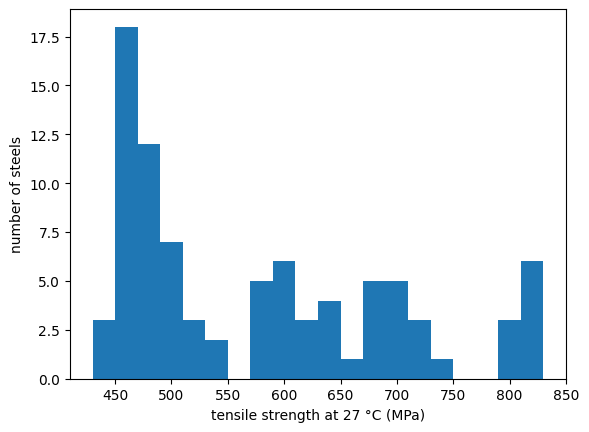

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.hist(room[strength_col], bins=20)
ax.set_xlabel('tensile strength at 27 °C (MPa)')
ax.set_ylabel('number of steels')

Most steels sit between about 430 and 600 MPa, and a tail of stronger steels runs out to about 830 MPa.

## Center: mean and median

In [8]:
print(f'{np.mean(room[strength_col]):.0f} {np.median(room[strength_col]):.0f}')  # mean, median

573 530


The mean (573 MPa) is above the median (530 MPa) because the tail of strong steels pulls the mean up.
The median depends on the middle of the sorted values; report 530 MPa as the typical strength here.

## Spread: standard deviation and percentiles

In [9]:
print(f'{np.std(room[strength_col]):.0f}')  # standard deviation

118


In [10]:
print(f'{np.percentile(room[strength_col], 10):.0f}')  # 10% of the steels are below this
print(f'{np.percentile(room[strength_col], 90):.0f}')  # 90% of the steels are below this

451
758


The middle 80% of these 87 steels fall between 451 and 758 MPa.
The percentiles describe these tested steels, not a guarantee for a new one.

### [Check your understanding]

Repeat the distribution for `' Elongation (%)'`, the stretch at fracture, in the same 87 room-temperature tests.

1. Plot a histogram of it with labeled axes.
2. Print its mean and median.
3. Print its 10th and 90th percentiles.
4. In a comment, say which printed number you would report as a typical elongation, and why. *(1-2 sentences)*

# Slicing, 2-D arrays, and `axis`

## One steel as an array

Select the tests for steel `MBB` and turn the temperature and strength columns into arrays:

In [11]:
is_mbb = steels['Alloy code'] == 'MBB'
mbb = steels.loc[is_mbb]
mbb_temp = mbb[temp_col].to_numpy()
mbb_strength = mbb[strength_col].to_numpy()
print(mbb_temp)
print(mbb_strength)

[ 27 100 200 300 400 450 500 550 600 650]
[490. 454. 465. 495. 489. 461. 431. 387. 314. 226.]


The two arrays are parallel: `mbb_strength[i]` was measured at `mbb_temp[i]`.

## Slice

In [12]:
print(mbb_temp[0:4])      # the first four temperatures
print(mbb_strength[0:4])  # the strengths at those temperatures

[ 27 100 200 300]
[490. 454. 465. 495.]


For MBB and the other steels we use today, the first four tests are at 27, 100, 200, and 300 °C.
The slice `[0:4]` selects those four temperatures for these steels.

Do the same for a second steel, `MBC`:

In [13]:
is_mbc = steels['Alloy code'] == 'MBC'
mbc_strength = steels.loc[is_mbc, strength_col].to_numpy()
print(mbc_strength[0:4])

[463. 427. 439. 471.]


## Stack into a 2-D array

In [14]:
low_temp = np.array([mbb_strength[0:4], mbc_strength[0:4]])
print(low_temp)
print(low_temp.shape)

[[490. 454. 465. 495.]
 [463. 427. 439. 471.]]
(2, 4)


Each row is one steel (row 0 is MBB, row 1 is MBC).
Each column is one temperature (27, 100, 200, 300 °C), so a column pairs the two steels at the same temperature.

## Index with `[row, column]`

In [15]:
print(low_temp[1, 2])  # row 1 is MBC, column 2 is 200 °C

439.0


## `axis=0` and `axis=1`

In [16]:
print(np.max(low_temp, axis=0))  # one value per column: the stronger steel at each temperature

[490. 454. 465. 495.]


In [17]:
print(np.max(low_temp, axis=1))  # one value per row: each steel's highest strength

[495. 471.]


`axis=0` collapses the rows and returns the larger strength at each temperature.
All four values come from row 0, so MBB is the stronger steel at every one of these temperatures.

`axis=1` collapses the columns, so it gives one number for each steel.

# Dictionaries and arrays

One test mixes text (the alloy code) with numbers (temperature and strength).
A dictionary keeps each value with its own type, under a name:

In [18]:
test = {'alloy': 'MBB', 'temp_C': 27, 'strength_MPa': 490}
print(test['strength_MPa'])

490


An array holds only one type, so NumPy turns all three values into text:

In [19]:
same_test = np.array(['MBB', 27, 490])
print(same_test)
print(type(same_test[2]))  # the strength is now text

['MBB' '27' '490']
<class 'numpy.str_'>


NumPy stored `490` as the string `'490'`, so it can no longer be used in arithmetic.
Use an array for many values of one kind, like `mbb_strength`, and a dictionary for one record with named fields of different kinds.

### [Check your understanding]

1. Build the same `[0:4]` strength slice for steel `MBD`.
2. Stack `mbb_strength[0:4]`, `mbc_strength[0:4]`, and your MBD slice into one 2-D array, and print its shape.
3. Print the MBD strength at 300 °C with `[row, column]` indexing.
4. Print `np.min` of the array with `axis=0`, and in a comment say what each of the printed values is. *(1-2 sentences)*

# Correlation and a fitted line

## Filter a second time

MBB's strength stays between 454 and 495 MPa up to 400 °C, then falls.
Keep only MBB's tests at 400 °C and above, with a second mask on the `mbb` table:

In [20]:
is_hot = mbb[temp_col] >= 400
mbb_hot = mbb.loc[is_hot]
print(len(mbb_hot))

6


Two filters, each with its own job: the first kept one steel, the second kept the hot tests of that steel.
The fit below describes these 6 tests only.

In [21]:
x = mbb_hot[temp_col]
y = mbb_hot[strength_col]

## `ax.plot` and `ax.scatter`

First, a comparison on the 87 room-temperature tests: tensile strength against carbon content.
`ax.plot` draws a line from each row to the next row of the table:

Text(0, 0.5, 'tensile strength at 27 °C (MPa)')

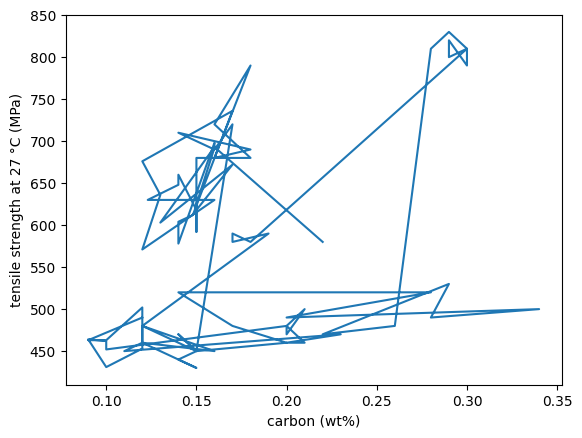

In [22]:
fig, ax = plt.subplots()
ax.plot(room[' C'], room[strength_col])
ax.set_xlabel('carbon (wt%)')
ax.set_ylabel('tensile strength at 27 °C (MPa)')

`ax.scatter` draws each test as its own point:

Text(0, 0.5, 'tensile strength at 27 °C (MPa)')

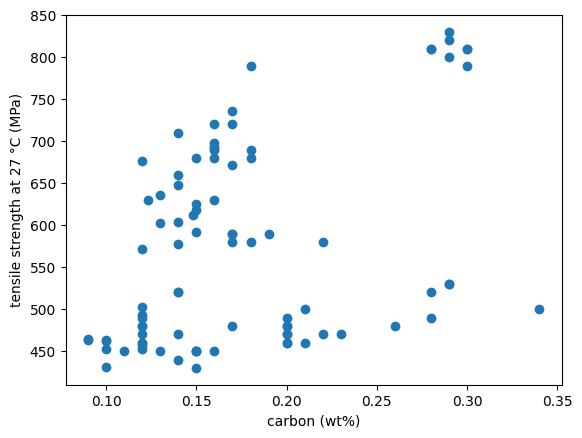

In [23]:
fig, ax = plt.subplots()
ax.scatter(room[' C'], room[strength_col])
ax.set_xlabel('carbon (wt%)')
ax.set_ylabel('tensile strength at 27 °C (MPa)')

Now plot MBB's six hot tests the same way:

Text(0, 0.5, 'tensile strength (MPa)')

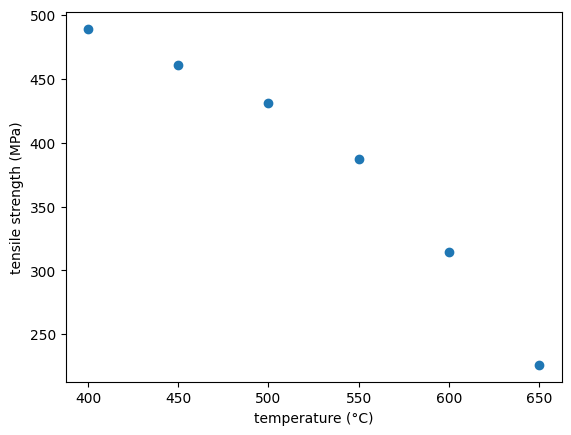

In [24]:
fig, ax = plt.subplots()
ax.scatter(x, y)
ax.set_xlabel('temperature (°C)')
ax.set_ylabel('tensile strength (MPa)')

## Correlation: `stats.pearsonr`

In [25]:
from scipy import stats

r, p = stats.pearsonr(x, y)
print(f'{r:.3f}')

-0.972


$r$ is negative, so strength goes down as temperature goes up.
It is close to $-1$, so the six tests lie close to a straight line.

## Fitted line: `stats.linregress`

In [26]:
fit = stats.linregress(x, y)
print(f'{fit.slope:.2f} {fit.intercept:.0f}')  # slope, intercept

-1.03 925


The fitted line is $\hat{y} = -1.03\,x + 925$.
For these tests, the fitted strength decreases by about 1 MPa per °C between 400 and 650 °C.

To draw the line, two points are enough: the lowest and highest temperature.

Text(0, 0.5, 'tensile strength (MPa)')

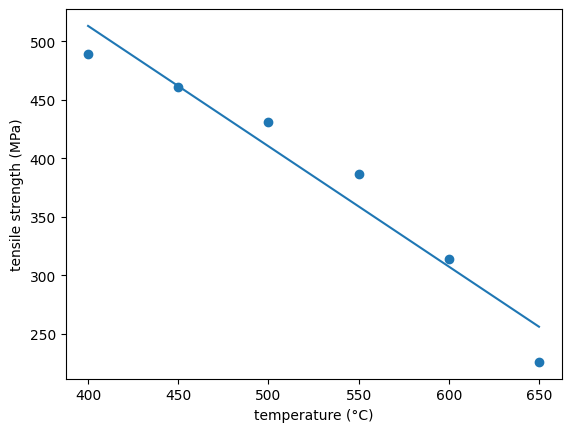

In [27]:
xx = np.array([np.min(x), np.max(x)])
yy = fit.slope * xx + fit.intercept

fig, ax = plt.subplots()
ax.scatter(x, y)
ax.plot(xx, yy)
ax.set_xlabel('temperature (°C)')
ax.set_ylabel('tensile strength (MPa)')

## $r$ and the slope

Both come from the same six tests, and both are negative because strength falls with temperature.

The slope is how steep the line is, in MPa per °C.
$r$ has no units; it is how closely the tests follow the line.

### [Check your understanding]

Repeat the fit for steel `CbC` at 400 °C and above.

1. Filter `steels` to CbC, then filter that table to 400 °C and above, and print the count.
2. Print $r$ from `stats.pearsonr` and the slope from `stats.linregress`.
3. In a comment, compare CbC with MBB: which steel loses strength faster, and which follows its line more closely? *(1-2 sentences)*

*Optional challenge:* draw CbC's scatter plot with its fitted line.

# Summary

**Reading and filtering a table**
* `print(steels.dtypes)` checks that a column is numeric before we take statistics of it.
* `.notna()` makes a mask of rows with a value; `.loc` with that mask kept 907 of 915 rows in this copy.
* `data.loc[mask]` keeps the rows where the mask is `True`, and a second mask can filter the result again.
* Every statistic describes only the rows that are left after filtering.

**Describing a distribution**
* A histogram shows the shape; a long tail pulls the mean away from the median.
* Here the upper tail raises the mean above the median; the standard deviation and percentiles describe the spread.

**Slicing, 2-D arrays, and `axis`**
* `a[0:4]` takes the first four values; `np.array([a, b])` stacks two slices as rows.
* `a[row, column]` picks one value; `axis=0` gives one result per column, `axis=1` one per row.

**Dictionaries and arrays**
* A dictionary retains named fields with their types; this array stores the text and numbers as strings.

**Correlation and a fitted line**
* `ax.plot` connects rows in table order; `ax.scatter` draws each test as its own point.
* Two endpoints and `ax.plot` draw the fitted line.
* The sign of $r$ is the direction and its size is how close the points are to the line; the slope is the steepness, in the units of $y$ per unit of $x$.

From MBB's hot tests: its tensile strength falls from 489 MPa at 400 °C to 226 MPa at 650 °C, about 1 MPa per degree.

## Further reading

* The data: NIMS [MatNavi](https://mits.nims.go.jp/en/), tensile tests on low-alloy steels; original course copy [steels.csv](https://github.com/wfreinhart/matse219/blob/main/datasets/steels.csv); the lecture loads `steels_with_gaps.csv`, with 8 strengths blanked for practice.